In [34]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
!cp "/content/drive/MyDrive/Mall_Customers.csv" "/content/"

# Clustering mall customers using k-means algorithm

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [37]:
data=pd.read_csv("Mall_Customers.csv")
print(data.head(),'\n\n\n')
print(data.info(),'\n\n\n')
print(data.describe())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40 



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None 



       CustomerID         Age  Annual Incom

According to the information above, we do not have missing values ​​in any of the data, and all data types except gender are numeric values.

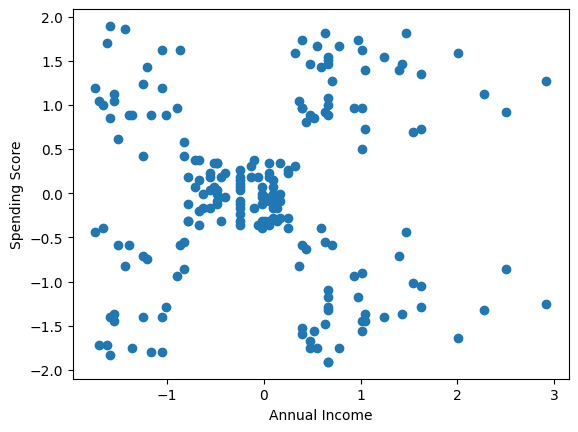

In [38]:
# Normalize Annual Income & Spending Score features
X=data.iloc[:,[3,4]].values
scaler=StandardScaler()
X=scaler.fit_transform(X)

# Scatter plot to see clients distribution
plt.scatter(X[:,0],X[:,1])
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

It seems that 5 clusters are the right number for the distribution of customers according to these two characteristics.

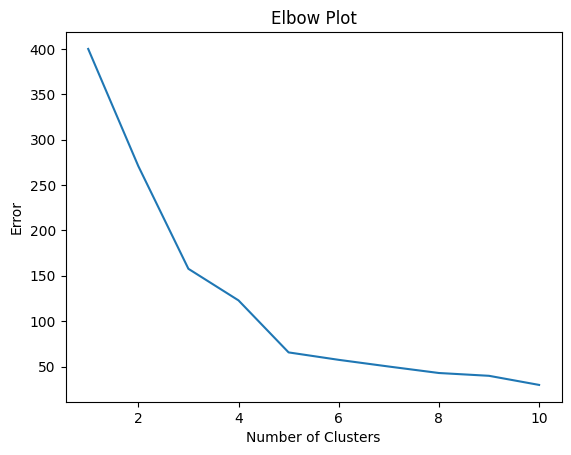

In [39]:
error_list=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,random_state=86)
  kmeans.fit(X)
  error_list.append(kmeans.inertia_)

# Elbow plot
plt.plot(range(1,11),error_list)
plt.xlabel('Number of Clusters')
plt.ylabel('Error')
plt.title('Elbow Plot')
plt.show()

According to the diagram above, the error with the lowest slope of the line has started from number 5. So the appropriate number of clusters is 5 clusters.

In [40]:
 kmeans=KMeans(n_clusters=5,random_state=86)
 y_pred=kmeans.fit_predict(X)
 data['Cluster']=y_pred
 print('Clusters centers:\n',kmeans.cluster_centers_)


Clusters centers:
 [[-1.30751869 -1.13696536]
 [-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [ 1.05500302 -1.28443907]
 [-1.32954532  1.13217788]]


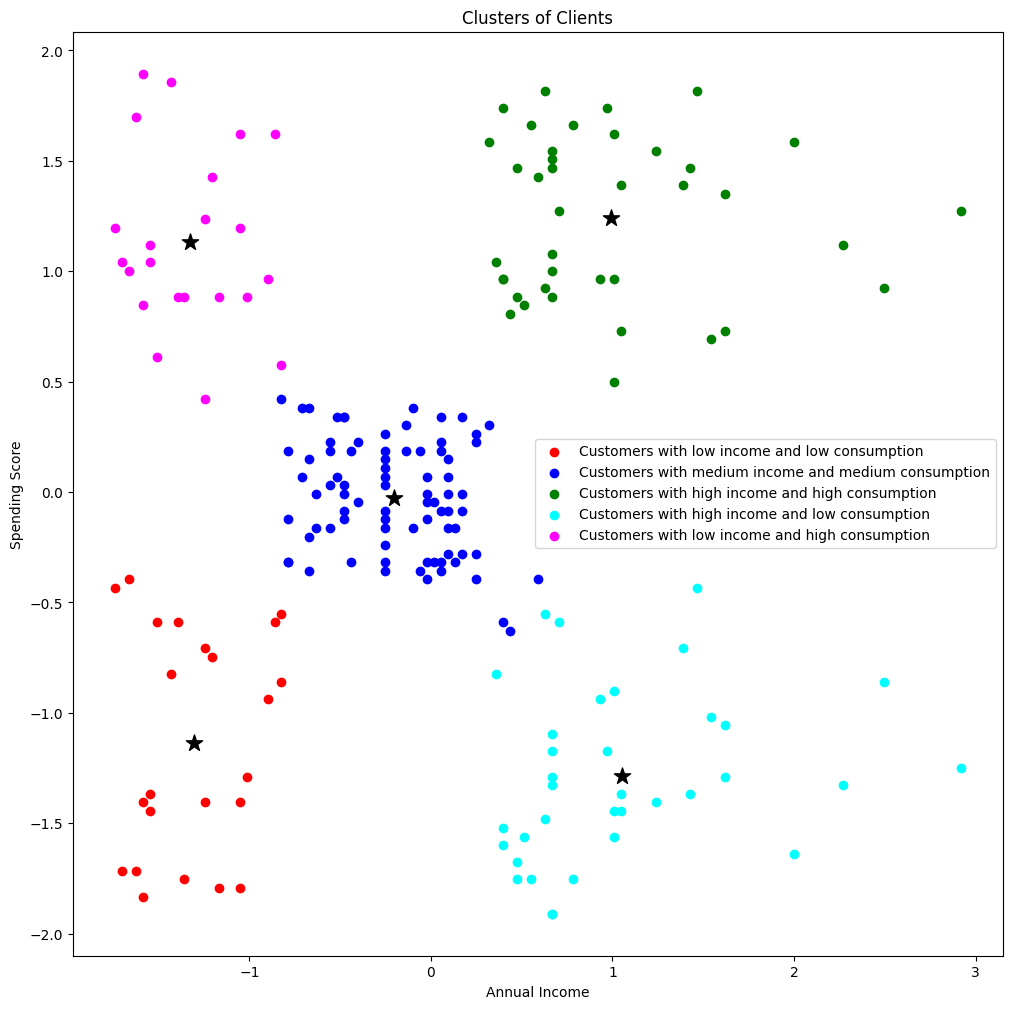

In [41]:
cluster_names={0:'Customers with low income and low consumption',
               1:'Customers with medium income and medium consumption',
               2:'Customers with high income and high consumption',
               3:'Customers with high income and low consumption',
               4:'Customers with low income and high consumption'}
colors=['red','blue','green','cyan','magenta']

plt.figure(figsize=(12,12))

for i in range(5):
  plt.scatter(X[y_pred==i,0],X[y_pred==i,1],c=colors[i],label=cluster_names[i])
  plt.legend()
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],c='black',marker='*',s=150)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Clusters of Clients')
plt.show()

In [42]:
print('Number of elements in each cluster:\n',data['Cluster'].value_counts())


Number of elements in each cluster:
 Cluster
1    81
2    39
3    35
0    23
4    22
Name: count, dtype: int64


In [43]:
silhouette=silhouette_score(X,y_pred)
print('Silhouette Score:',silhouette)

Silhouette Score: 0.5546571631111091


The above number for the silhouette_score indicates that the number of clusters is reasonable and appropriate, and these two features were sufficient for customer clustering.